# What is Quantization?
Quantization is a technique that enables models to execute more quickly and consume less memory. By transforming 32-bit floating-point numbers (the float32 data type) into lower-precision formats such as 8-bit integers (the int8 data type), the computational demands of our models can be decreased. 

In other words, quantization involves mapping an input from a broad range to a more limited set of values. In deep learning, this technique is employed to decrease the precision of the weights and activations in neural network models.


# How Quantization Works? (float32 -> int8)
Performing quantization to go from float32 to int8 is tricky. Only 256 distinct values can be represented using int8, while float32 can represent a much broader range. The goal is to determine the most effective way to map the range [a, b] of float32 values into the int8 space.

For a float value 𝑥 within [a, b], the quantization process, also known as affine quantization, can be expressed as follows:

**x = S . (x_q - Z)**

where:
* **x_q** is the quantized int8 value corresponding to x,
* **S** and **Z** are the quantization parameters,
* **S** represents the scale and is a positive float32 value,
* **Z** is the zero-point, which is the int8 value representing 0 in the float32 space. This is crucial for accurately representing the value 0, which is widely used in machine learning models.

{**affine quantization:** A function that can be expressed as a combination of a linear transformation and a translation in any-dimensional Euclidean space, specifically written as Ax + b, where A is a matrix and b is a vector.}

The quantized value x_q of x in [a, b] can be computed as follows:

**x_q = round(x/S + Z)**

And float32 values outside of the [a, b] range are clipped to the closest representable value, so for any floating-point number x:

**x_q = clip(round(x/S + Z), round(a/S + Z), round(b/S + Z))**

---

***Per-tensor and per-channel quantization***

Depending on the desired balance between accuracy and latency, you can adjust the granularity of the quantization parameters:

- **Per-tensor quantization**: In this approach, a single pair of (S, Z) is used for each tensor.
- **Per-channel quantization**: Here, you compute a separate pair of (S, Z) for each element along one dimension of the tensor. For instance, for a tensor with shape [N, C, H, W], using per-channel quantization for the second dimension would yield C pairs of (S, Z). This method can improve accuracy but requires more memory.


# Calibration
The previous section explained the process of quantizing float32 values to int8, but one key question remains: how is the range [a, b] for float32 values determined? This is where calibration comes into play.

**Calibration** is the stage in quantization where the float32 ranges are established. Determining these ranges for weights is straightforward since the actual range is known at quantization time. However, determining the ranges for activations is more complex and involves different approaches:

- **Post-training dynamic quantization**: The range for each activation is calculated dynamically during runtime. While this method provides good results with minimal effort, it can be slower than static quantization due to the overhead of range computation at each step. It may also be incompatible with some hardware.

- **Post-training static quantization**: The range for each activation is computed ahead of time, typically by processing representative data through the model and recording activation values. The steps involved are:
  - Observers are attached to activations to record their values.
  - The model undergoes several forward passes using a calibration dataset (usually around 200 examples).
  - The ranges for each activation are determined using a calibration technique.
  
  
  Since PTQ-static is used in this notebook, it is useful to detail PTQ.
  
  ---
  # What is Post-Training Quantization (PTQ)?
  
  Post-Training Quantization (PTQ) is a technique used to reduce the size of deep learning models by quantizing their weights and activations. This approach enables more efficient deployment on devices with limited resources. PTQ reduces the memory footprint of models by mapping floating-point operations to lower-bit representations. As a result, the model size is significantly decreased while maintaining detection accuracy. This makes PTQ an effective solution for optimizing memory usage and facilitating deployment on edge devices. By preserving the model’s detection performance, PTQ is a valuable method for enhancing memory efficiency in object detection tasks.

  ---

- **Quantization-aware training**: The range for each activation is calculated during training, similar to post-training static quantization. However, instead of using observers, "fake quantize" operators are employed. These operators simulate quantization errors to help the model adapt to them.

For both post-training static quantization and quantization-aware training, various calibration techniques are used, including:

- **Min-max**: This technique computes the range as [min observed value, max observed value], and it works well for weights.
  
- **Moving average min-max**: This technique calculates the range as [moving average min observed value, moving average max observed value], which is effective for activations.
  
- **Histogram**: This approach records a histogram of values along with min and max values, then chooses the range based on specific criteria:
  - **Entropy**: The range is selected to minimize the error between the full-precision and quantized data.
  - **Mean Square Error**: The range is chosen to minimize the mean square error between the full-precision and quantized data.
  - **Percentile**: The range is determined using a specified percentile value \( p \) from the observed values. The goal is to include \( p \% \) of the observed values within the computed range. While this method works well for affine quantization, it may not always be exact with symmetric quantization. For further details, see how it's implemented in ONNX Runtime.

# QUANTIZATION

In [1]:
!pip install torch torchvision
!pip install onnx onnxruntime
!pip install ultralytics
!pip install -U opencv-python

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.2/13.2 MB 53.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.0/46.0 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.8/86.8 kB 4.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.3/41.3 kB 603.6 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 869.0/869.0 kB 5.8 MB/s eta 0:00:00


In [3]:
from ultralytics import YOLO

model = YOLO('models/trainedv8s.pt')  # Load the trained model

# Export the model to ONNX format
model.export(format = 'onnx') 

Ultralytics YOLOv8.0.231 🚀 Python-3.11.9 torch-2.5.1+cpu CPU (12th Gen Intel Core(TM) i3-1220P)
Model summary (fused): 169 layers, 11126745 parameters, 0 gradients

PyTorch: starting from 'models\trainedv8s.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 7, 8400) (21.5 MB)
requirements: Ultralytics requirement ['onnx>=1.12.0'] not found, attempting AutoUpdate...
   ---------------------------------------- 16.4/16.4 MB 11.1 MB/s  0:00:01:01
   ---------------------------------------- 3/3 [onnx]buf]

requirements: AutoUpdate success ✅ 10.4s, installed 1 package: ['onnx>=1.12.0']
requirements: ⚠️ Restart runtime or rerun command for updates to take effect


ONNX: starting export with onnx 1.21.0 opset 19...
ONNX: export success ✅ 11.7s, saved as 'models\trainedv8s.onnx' (42.6 MB)

Export complete (14.1s)
Results saved to D:\Project\trash-detection\models
Predict:         yolo predict task=detect model=models\trainedv8s.onnx imgsz=640  
Validate:        yolo val task=det

'models\\trainedv8s.onnx'

In [4]:
#Preprocessing the model
!python -m onnxruntime.quantization.preprocess --input models/trainedv8s.onnx --output models/pre.onnx  

In [5]:
#STATIC QUANTIZATION
import numpy as np
import os
from onnxruntime.quantization import CalibrationDataReader, quantize_static, QuantType, QuantFormat
import cv2 as cv

class CustomCalibrationDataReader(CalibrationDataReader):
    def __init__(self, image_paths):
        self.image_paths = image_paths
        self.idx = 0
        self.input_name = "images"
        
    def preprocess(self,frame):
        frame = cv.imread(frame)
        X = cv.resize(frame, (640,640))
        image_data = np.array(X).astype(np.float32) / 255.0 #Normalize to 0-1 range
        image_data = np.transpose(image_data, (2, 0, 1)) #Converting from HWC to CHW (first one is "Channel"; PyTorch Format)
        image_data = np.expand_dims(image_data, axis=0) #Add batch dimension
        """
    'image_data' olarak adlandırılan görüntü verisine bir batch (yığın) boyutu ekler. Modeller genellikle birden fazla görüntü veya veri örneğini 
    aynı anda işlemek üzere tasarlanmıştır.Bu süreçte batch boyutu, modelin giriş verilerini belirli bir şekil formatında almasını sağlar.
        """
        return image_data
    
    def get_next(self):
        if self.idx >= len(self.image_paths):
            return None
        
        image_path = self.image_paths[self.idx]
        input_data = self.preprocess(image_path)
        self.idx += 1
        return {self.input_name: input_data}

    
def get_image_paths_from_directory(directory):
    all_files = os.listdir(directory)
    
    image_files = [file for file in all_files if os.path.isfile(os.path.join(directory, file))]
    image_paths = [os.path.join(directory, file) for file in image_files]
    
    return image_paths

calibration_dir = 'datasets/images/val'    
    
#These images will be processed by the CustomCalibrationDataReader to gather necessary data for quantization.
calibration_image_paths = get_image_paths_from_directory(calibration_dir)
   
#Create an instance of the CustomCalibrationDataReader
calibration_data_reader = CustomCalibrationDataReader(calibration_image_paths)

***CODE EXPLANATION***

> **import numpy as np
from onnxruntime.quantization import CalibrationDataReader, quantize_static, QuantType, QuantFormat
import cv2 as cv**

* for numerical operations => *numpy*
* for quantization operations =>*CalibrationDataReader, quantize_static, QuantType, and QuantFormat from onnxruntime.quantization*
* for image processing tasks => *cv2*


> **class CustomCalibrationDataReader(CalibrationDataReader):**

This class inherits from CalibrationDataReader, which is a base class for providing calibration data for quantization.

--------------------------------------------------------------------------------------------------------------------------------------------

> __init__ Method

Initializes an instance of the class.
* ***image_paths:*** This parameter is a list of file paths to images used for calibration.
* ***self.idx:*** Initializes the index to 0, which keeps track of the current image being processed.
* ***self.input_name:*** Sets the name of the input tensor, which is used during quantization to identify the data.

--------------------------------------------------------------------------------------------------------------------------------------------

> **preprocess** Method

This method processes an image file path (frame) and converts it into a format suitable for model input.
* ***cv.imread(frame):*** Reads the image from the file path.
* ***cv.resize(frame, (640, 640))*** ***:*** Resizes the image to 640x640 pixels.
* ***np.array(X).astype(np.float32) / 255.0*** ***:*** Converts the image to a NumPy array, normalizes pixel values to the range [0, 1].
* ***np.transpose(image_data, (2, 0, 1)):*** Changes the image data format from HWC (Height, Width, Channels) to CHW (Channels, Height, Width), which is the format commonly used in PyTorch models.
* ***np.expand_dims(image_data, axis=0):*** Adds a batch dimension to the image data, converting it from a single image to a batch of one image. This is necessary because models often expect input in batch format.

--------------------------------------------------------------------------------------------------------------------------------------------

***{***

***Additional Turkish Explanation***

Derin öğrenme modelleri, genellikle giriş verilerini (batch_size, height, width, channels) veya (batch_size, channels, height, width) formatında bekler:

* **batch_size:** Aynı anda işlenecek görüntü sayısıdır. Eğitim veya çıkarım işlemlerinde birden fazla görüntü kullanılarak işlem yapılabilir.
* **height:** Görüntünün yüksekliği.
* **width:** Görüntünün genişliği.
* **channels:** Görüntünün kanalları (örneğin, RGB görüntü için 3 kanal).

        image_data = np.expand_dims(image_data, axis=0)

Bu satır, *image_data*'ya bir batch boyutu ekler. Eğer *image_data*'nın orijinal şekli *(height, width, channels)* ise, **np.expand_dims** ile bu şekil *(1, height, width, channels)* haline gelir. Bu, modeli tek bir görüntü ile beslemenizi sağlar, ancak şekil formatı modelin beklediği şekilde olur.

***}***

--------------------------------------------------------------------------------------------------------------------------------------------

> **get_next** Method

This method provides the next batch of calibration data.
* If **self.idx** is greater than or equal to the length of **image_paths**, it returns **None**, indicating no more data is available.
* Otherwise, it retrieves the current image path, preprocesses it, increments the index, and returns the preprocessed image data in a dictionary format with **self.input_name** as the key.

# Finding the nodes to exclude

To find that, go to https://netron.app/ and upload the model(*'yolov8s.onnx'*). After uploading scroll to the bottom and select the nodes in the bottom layers to collect the names

In [ ]:
#Use the calibration_data_reader with quantize_static
quantize_static(
    'models/pre.onnx', 'models/static_quantized.onnx',
    weight_type = QuantType.QInt8,
    activation_type = QuantType.QUInt8, 
    calibration_data_reader = calibration_data_reader,
    quant_format = QuantFormat.QDQ,
    nodes_to_exclude = [
        '/model.22/Concat_3', '/model.22/Split',
        '/model.22/dfl/Reshape','/model.22/dfl/Transpose','/model.22/dfl/Softmax','/model.22/dfl/conv/Conv','/model.22/dfl/Reshape_1',
        '/model.22/Slice','/model.22/Slice_1','/model.22/Sub','/model.22/Add_1','/model.22/Div_1','/model.22/Concat_4','/model.22/Mul_2'
        '/model.22/Sigmoid','/model.22/Concat_5'
    ],
    per_channel = False,
    reduce_range = True
)

> **quantize_static** Function

This function performs static quantization on an ONNX model, converting it from floating-point precision to lower precision, such as int8. It takes several parameters to guide the quantization process.

    Parameters:
* *`'/kaggle/working/pre.onnx':`* The path to the input ONNX model that you want to quantize.

* *`'/kaggle/working/static_quantized.onnx':`* The path where the quantized ONNX model will be saved.

* *`weight_type = QuantType.QInt8:`* Specifies that weights should be quantized to 8-bit integers (int8).

* *`activation_type = QuantType.QUInt8:`* Specifies that activations should be quantized to 8-bit unsigned integers (uint8).

* *`calibration_data_reader = calibration_data_reader:`* Uses the calibration_data_reader object to provide the calibration data needed for quantization. This object processes the images and provides the necessary information to determine the range of values for quantization.

* *`quant_format = QuantFormat.QDQ:`* Sets the quantization format to QDQ (Quantize-Dequantize). This format is used to apply quantization and dequantization operations to the model.

* *`nodes_to_exclude = [...]:`* Lists the nodes in the model that should be excluded from quantization. These nodes are specified by their names or paths and are left in their original floating-point format. This is often done to ensure that quantization does not affect certain operations or layers that are sensitive to quantization errors.

* *`per_channel = False:`* Indicates that the quantization parameters (scale and zero-point) should be shared across all channels, rather than being computed separately for each channel. If True, it would use per-channel quantization.

* *`reduce_range = True:`* When set to True, this parameter reduces the range of quantization for activations. It limits the range of values to better fit within the 8-bit representation, which can help improve performance and reduce errors in some cases.
--------------------------------------------------------------------------------------------------------------------------------------------


# INFERENCE
Inference is the process of using a trained machine learning model to make predictions or draw conclusions from new data. During inference, the model applies the patterns and knowledge it learned during training to unseen input data. This allows the model to perform tasks such as classification, object detection, or regression based on the input it receives. 

In [2]:
#IMPORTING NECESSARY LIBRARIES

import onnxruntime as ort #Is used for running inference with ONNX models. It provides efficient runtime for executing models in the ONNX format.
import numpy as np #for numerical computations in Python. It provides support for arrays, mathematical functions, and operations on large datasets.
import time 
import cv2 as cv #for image processing tasks, such as reading, writing, and manipulating images.


In [3]:
import cv2 as cv
import numpy as np
import onnxruntime as ort

def preprocessor(frame): 
    x = cv.resize(frame, (640, 640))
    image_data = np.array(x).astype(np.float32) / 255.0  # Normalize to 0-1 range
    image_data = np.transpose(image_data, (2, 0, 1))  # Converting from HWC to CHW (first one is "Channel"; PyTorch Format)
    image_data = np.expand_dims(image_data, axis=0)  # Add batch dimension
    return image_data

class Inference:
    def __init__(self, model, path):
        self.session = ort.InferenceSession(model, providers=["CPUExecutionProvider"])
        model_inputs = self.session.get_inputs()
        input_shape = model_inputs[0].shape
        self.path = path
        self.input_width = input_shape[2]
        self.input_height = input_shape[3]
        self.classes = {
            0: 'paper', 1: 'plastic', 2: 'glass'
        }
    

    def detector(self, image_data):
        onnx_rt = ort.OrtValue.ortvalue_from_numpy(image_data)
        return self.session.run(["output0"], {"images": onnx_rt})
    
    def draw_boxes(self,image, results, class_names):
        for result in results:
            box = result['box']
            score = result['score']
            class_id = result['class_id']

            # Sınıf adını almak için
            class_name = class_names.get(class_id, 'Unknown')

            # Renk ve kalınlık ayarları
            color = (0, 255, 0)  # Yeşil
            thickness = 2

            # Box'u çiz
            cv.rectangle(image, (int(box[0]), int(box[1])), (int(box[0] + box[2]), int(box[1] + box[3])), color, thickness)

            # Sınıf ve skoru yaz
            text = f'{class_name}: {score:.2f}'
            cv.putText(image, text, (int(box[0]), int(box[1]) - 10), cv.FONT_HERSHEY_SIMPLEX, 0.5, color, 2)

        return image

    
    def postprocessor(self, results, frame, confidence, iou):
        img_height, img_width = frame.shape[:2]
        outputs = np.transpose(np.squeeze(results[0]))
        rows = outputs.shape[0]
        boxes = []
        scores = []
        class_ids = []
        
        x_factor = img_width / self.input_width #640
        y_factor = img_height / self.input_height #640
        
        for i in range(rows):
            classes_scores = outputs[i][4:]
            max_score = np.amax(classes_scores)
            if max_score >= confidence:
                class_id = np.argmax(classes_scores) #Get the class id with the highest score
                x, y, w, h = outputs[i][0], outputs[i][1], outputs[i][2], outputs[i][3] #Extract the bounding box coordinates from the current row
               
                #Calculate the scaled coodinates of the bounding box
                left = int((x - w / 2) * x_factor)
                top = int((y - h / 2) * y_factor)
                width = int(w * x_factor)
                height = int(h * y_factor)
                
                class_ids.append(class_id)
                scores.append(max_score)
                boxes.append([left, top, width, height])
        
        #Apply non-maximum suppression to filter out overlapping bounding boxes
        indices = cv.dnn.NMSBoxes(boxes, scores, confidence, iou)
        return [{'box': boxes[i], 'score': scores[i], 'class_id': class_ids[i]} for i in indices]

    def pipeline(self):
        frame = cv.imread(self.path)
        results = self.detector(preprocessor(frame))
        detections = self.postprocessor(results, frame, 0.35, 0.35)
        return detections
    
    def predict_image(self, image_path, conf=0.35, iou=0.35):
        frame = cv.imread(image_path)
        results = self.detector(preprocessor(frame))
        detections = self.postprocessor(results, frame, conf, iou)
        return detections

    def predict_directory(self, image_dir, output_dir=None, conf=0.35, iou=0.35):
        import os
        os.makedirs(output_dir, exist_ok=True)
        
        image_files = [f for f in os.listdir(image_dir) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
        results = []
        
        for img_file in image_files:
            img_path = os.path.join(image_dir, img_file)
            detections = self.predict_image(img_path, conf, iou)
            results.append({'image': img_file, 'detections': detections})
            
            if output_dir:
                frame = cv.imread(img_path)
                output_img = self.draw_boxes(frame, detections, self.classes)
                cv.imwrite(os.path.join(output_dir, img_file), output_img)
        
        return results
    

In [15]:
# Demo: Run inference on your custom dataset
# Use FLOAT32 model (onnx) or INT8 quantized model

# Option 1: Use FP32 ONNX model
# model_path = 'models/trainedv8s.onnx'

# Option 2: Use INT8 quantized model (after quantization)
model_path = 'models/static_quantized.onnx'

# Create inference instance
inference = Inference(model_path, '')

# Run on single image
image_path = 'datasets/images/val/glass_69_jpg.rf.abec512863fe66073c05b659402fb653.jpg'
detections = inference.predict_image(image_path, conf=0.35, iou=0.35)
print(f"Image: {image_path}")
print(f"Detections: {detections}")

# Visualize result
img = cv.imread(image_path)
output_img = inference.draw_boxes(img, detections, inference.classes)
cv.imshow('Detection Result', output_img)
cv.waitKey(0)
cv.destroyAllWindows()

# Or run on entire validation directory
# results = inference.predict_directory('datasets/images/val', 'output/val_results')
# print(f"Processed {len(results)} images")

Image: datasets/images/val/glass_69_jpg.rf.abec512863fe66073c05b659402fb653.jpg
Detections: [{'box': [284, 90, 349, 439], 'score': np.float32(0.62512344), 'class_id': np.int64(2)}]


    __init__(self, model, path):
Initializes the Inference class with two parameters: model and path.

* ***self.session:*** Creates an inference session using the ONNX Runtime (ort) with the specified model. It uses the CPU for execution (CPUExecutionProvider).
* ***model_inputs:*** Retrieves the input information of the model, such as shape.
* ***input_shape:*** Gets the shape of the model's input tensor.
* ***self.path:*** Stores the path to the image file for inference.
* ***self.input_width and self.input_height:*** Set the width and height of the input images based on the model's requirements.
* ***self.classes:*** Defines a dictionary mapping class IDs to class names, representing different object categories that the model can detect.

---

    detector(self, image_data):
Takes **image_data** (preprocessed image) as input.

Converts the numpy array to ONNX Runtime format using **`ort.OrtValue.ortvalue_from_numpy()`**.

Runs inference on the model using the ONNX Runtime **session** and returns the result for the output named "**output0**".

---

    draw_boxes(self,image, results, class_names): 
Draws bounding boxes on the image based on detection results and class names.

* ***image:*** The image on which the bounding boxes and class names will be drawn.
* ***results:*** A list of detection results, where each result contains:
* ***box:*** Bounding box coordinates in the format **`[x, y, width, height].`**
* ***score:*** Confidence score of the detection.
* ***class_id:*** Identifier for the detected class.
* ***class_names:*** A dictionary mapping class IDs to their corresponding class names.

Iterates through the detection results and performs the following:

* ***class_name:*** Retrieves the class name using the class ID. Defaults to '**Unknown**' if the class ID is not in the dictionary.
* ***color:*** Defines the color of the bounding box and text. Set to green **(0, 255, 0)**.
* ***thickness:*** Sets the thickness of the bounding box lines. Set to 2.

Draws the bounding box on the image:

* Uses OpenCV's cv.rectangle function to draw a rectangle with the specified color and thickness. The rectangle is defined by the top-left corner `(int(box[0]), int(box[1]))` and the bottom-right corner `(int(box[0] + box[2]), int(box[1] + box[3]))`.

Annotates the image with the class name and score:

* Constructs a text label containing the class name and confidence score in the format **`{class_name}: {score:.2f}`**.
* Uses OpenCV's `cv.putText` function to draw the text on the image, positioning it just above the top-left corner of the bounding box. The text color and thickness are set to the same as the bounding box.

Returns the annotated image with bounding boxes and class labels.

---

    postprocessor(self, results, frame, confidence, iou):
Post-processes the inference results to filter and visualize detections.

* ***img_height, img_width:*** Dimensions of the input frame.
* ***outputs:*** Transposes and squeezes the output from the inference results.
* ***boxes, scores, class_ids:*** Lists to store detection results.
* ***x_factor and y_factor:*** Scaling factors to map bounding box coordinates from the model input size to the image size.

Iterates through detected objects, computes scaled bounding box coordinates, and filters detections based on confidence.

* ***cv.dnn.NMSBoxes:*** Applies Non-Maximum Suppression to remove redundant bounding boxes.

Draws remaining detections on the frame and returns the annotated frame.

---

    pipeline(self):
Executes the end-to-end inference pipeline.

Reads the image from the specified path using OpenCV.

Preprocesses the image, performs detection, post-processes the results, and applies Non-Maximum Suppression.

Returns the final annotated frame with detected objects.

# Dataset
Note: This notebook uses the custom dataset located at `datasets/`. The validation images are in `datasets/images/val/` and labels in `datasets/labels/val/`.

In [16]:
# Check dataset structure
import os
print("Images in validation folder:", len(os.listdir('datasets/images/val')))
print("Labels in validation folder:", len(os.listdir('datasets/labels/val')))

Images in validation folder: 1012
Labels in validation folder: 1012


# EVALUATION

In [25]:
import numpy as np
import os
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

# Helper functions for YOLO label evaluation
def load_yolo_labels(label_dir):
    """Load YOLO format ground truth labels from directory."""
    labels = {}
    label_dir = Path(label_dir)
    for label_file in sorted(label_dir.glob('*.txt')):
        img_name = label_file.stem
        boxes = []
        with open(label_file, 'r') as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) >= 5:
                    class_id, x_c, y_c, w, h = map(float, parts[:5])
                    boxes.append((int(class_id), x_c, y_c, w, h))
        if boxes:
            labels[img_name] = boxes
    return labels

def convert_yolo_to_xyxy(x_c, y_c, w, h, img_w=640, img_h=640):
    """Convert YOLO (x_c, y_c, w, h) to pixel (x1, y1, x2, y2) format."""
    x1 = int((x_c - w/2) * img_w)
    y1 = int((y_c - h/2) * img_h)
    x2 = int((x_c + w/2) * img_w)
    y2 = int((y_c + h/2) * img_h)
    return max(0, x1), max(0, y1), min(img_w, x2), min(img_h, y2)

def compute_iou(box1, box2):
    """Compute IoU between two boxes in xyxy format."""
    x1_min, y1_min, x1_max, y1_max = box1
    x2_min, y2_min, x2_max, y2_max = box2
    
    inter_x1 = max(x1_min, x2_min)
    inter_y1 = max(y1_min, y2_min)
    inter_x2 = min(x1_max, x2_max)
    inter_y2 = min(y1_max, y2_max)
    
    if inter_x2 <= inter_x1 or inter_y2 <= inter_y1:
        return 0.0
    
    inter_area = (inter_x2 - inter_x1) * (inter_y2 - inter_y1)
    box1_area = (x1_max - x1_min) * (y1_max - y1_min)
    box2_area = (x2_max - x2_min) * (y2_max - y2_min)
    union_area = box1_area + box2_area - inter_area
    
    return inter_area / union_area if union_area > 0 else 0.0

def match_predictions_to_gt(predictions, ground_truth, iou_threshold=0.5, img_w=640, img_h=640):
    """Match predictions to ground truth using IoU threshold."""
    tp_per_class = {0: 0, 1: 0, 2: 0}
    fp_per_class = {0: 0, 1: 0, 2: 0}
    fn_per_class = {0: 0, 1: 0, 2: 0}
    
    # Convert predictions to xyxy
    pred_boxes = []
    for x_c, y_c, w, h, conf, class_id in predictions:
        xyxy = convert_yolo_to_xyxy(x_c, y_c, w, h, img_w, img_h)
        pred_boxes.append((xyxy, conf, class_id))
    
    # Convert ground truth to xyxy
    gt_boxes = []
    for class_id, x_c, y_c, w, h in ground_truth:
        xyxy = convert_yolo_to_xyxy(x_c, y_c, w, h, img_w, img_h)
        gt_boxes.append((xyxy, class_id))
    
    matched_gt = [False] * len(gt_boxes)
    pred_boxes_sorted = sorted(enumerate(pred_boxes), key=lambda x: x[1][1], reverse=True)
    
    for _, (pred_box, conf, pred_class) in pred_boxes_sorted:
        best_iou = 0
        best_gt_idx = -1
        
        for gt_idx, (gt_box, gt_class) in enumerate(gt_boxes):
            if matched_gt[gt_idx] or pred_class != gt_class:
                continue
            
            iou = compute_iou(pred_box, gt_box)
            if iou > best_iou:
                best_iou = iou
                best_gt_idx = gt_idx
        
        if best_iou >= iou_threshold and best_gt_idx >= 0:
            tp_per_class[pred_class] += 1
            matched_gt[best_gt_idx] = True
        else:
            fp_per_class[pred_class] += 1
    
    for gt_idx, (_, gt_class) in enumerate(gt_boxes):
        if not matched_gt[gt_idx]:
            fn_per_class[gt_class] += 1
    
    return tp_per_class, fp_per_class, fn_per_class

# Load ground truth labels
print("\n" + "="*80)
print("EVALUATION: Computing Accuracy Metrics on Validation Set")
print("="*80)
print("\nLoading ground truth labels from datasets/labels/val/...")
gt_labels = load_yolo_labels('datasets/labels/val')
print(f"Loaded {len(gt_labels)} ground truth files")

# Get validation images
val_img_dir = Path('datasets/images/val')
val_images = sorted([f for f in val_img_dir.glob('*.jpg')] + [f for f in val_img_dir.glob('*.png')])
print(f"Found {len(val_images)} validation images")

# Evaluate FP32 model
print("\n" + "-"*80)
print("Evaluating FP32 Model...")
print("-"*80)

fp32_tp = {0: 0, 1: 0, 2: 0}
fp32_fp = {0: 0, 1: 0, 2: 0}
fp32_fn = {0: 0, 1: 0, 2: 0}

for i, img_path in enumerate(val_images):
    if (i + 1) % 200 == 0:
        print(f"  Processed {i+1}/{len(val_images)} images")
    
    img_name = img_path.stem
    if img_name not in gt_labels:
        continue
    
    # Get predictions from FP32 model
    detections = fp32_inference.predict_image(str(img_path))
    
    # Convert to YOLO format for matching
    pred_boxes = []
    for det in detections:
        x1, y1, w, h = det['box']
        x2, y2 = x1 + w, y1 + h
        x_c = (x1 + x2) / 2 / 640
        y_c = (y1 + y2) / 2 / 640
        w_norm = w / 640
        h_norm = h / 640
        pred_boxes.append((x_c, y_c, w_norm, h_norm, float(det['score']), det['class_id']))
    
    tp, fp, fn = match_predictions_to_gt(pred_boxes, gt_labels[img_name])
    for c in [0, 1, 2]:
        fp32_tp[c] += tp[c]
        fp32_fp[c] += fp[c]
        fp32_fn[c] += fn[c]

print("FP32 Evaluation Complete")

# Evaluate INT8 model
print("\n" + "-"*80)
print("Evaluating INT8 Model...")
print("-"*80)

int8_tp = {0: 0, 1: 0, 2: 0}
int8_fp = {0: 0, 1: 0, 2: 0}
int8_fn = {0: 0, 1: 0, 2: 0}

for i, img_path in enumerate(val_images):
    if (i + 1) % 200 == 0:
        print(f"  Processed {i+1}/{len(val_images)} images")
    
    img_name = img_path.stem
    if img_name not in gt_labels:
        continue
    
    # Get predictions from INT8 model
    detections = int8_inference.predict_image(str(img_path))
    
    # Convert to YOLO format for matching
    pred_boxes = []
    for det in detections:
        x1, y1, w, h = det['box']
        x2, y2 = x1 + w, y1 + h
        x_c = (x1 + x2) / 2 / 640
        y_c = (y1 + y2) / 2 / 640
        w_norm = w / 640
        h_norm = h / 640
        pred_boxes.append((x_c, y_c, w_norm, h_norm, float(det['score']), det['class_id']))
    
    tp, fp, fn = match_predictions_to_gt(pred_boxes, gt_labels[img_name])
    for c in [0, 1, 2]:
        int8_tp[c] += tp[c]
        int8_fp[c] += fp[c]
        int8_fn[c] += fn[c]

print("INT8 Evaluation Complete")

# Compute metrics
class_names = {0: 'paper', 1: 'plastic', 2: 'glass'}

def compute_metrics(tp, fp, fn, class_names):
    metrics = {}
    for c_id, c_name in class_names.items():
        t = tp[c_id]
        f = fp[c_id]
        n = fn[c_id]
        
        precision = t / (t + f) if (t + f) > 0 else 0
        recall = t / (t + n) if (t + n) > 0 else 0
        f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
        
        metrics[c_name] = {
            'precision': precision,
            'recall': recall,
            'f1': f1,
            'tp': t,
            'fp': f,
            'fn': n
        }
    return metrics

fp32_metrics = compute_metrics(fp32_tp, fp32_fp, fp32_fn, class_names)
int8_metrics = compute_metrics(int8_tp, int8_fp, int8_fn, class_names)

# Display results
print("\n" + "="*80)
print("RESULTS: FP32 vs INT8 Model Accuracy")
print("="*80)

print("\n" + "-"*80)
print("FP32 Model Metrics")
print("-"*80)
for c_name, metrics in fp32_metrics.items():
    print(f"\n{c_name.upper()}:")
    print(f"  Precision: {metrics['precision']:.4f}")
    print(f"  Recall:    {metrics['recall']:.4f}")
    print(f"  F1-Score:  {metrics['f1']:.4f}")
    print(f"  TP/FP/FN:  {metrics['tp']}/{metrics['fp']}/{metrics['fn']}")

print("\n" + "-"*80)
print("INT8 Model Metrics")
print("-"*80)
for c_name, metrics in int8_metrics.items():
    print(f"\n{c_name.upper()}:")
    print(f"  Precision: {metrics['precision']:.4f}")
    print(f"  Recall:    {metrics['recall']:.4f}")
    print(f"  F1-Score:  {metrics['f1']:.4f}")
    print(f"  TP/FP/FN:  {metrics['tp']}/{metrics['fp']}/{metrics['fn']}")

# Compute and display quantization impact
print("\n" + "-"*80)
print("Quantization Impact (INT8 vs FP32)")
print("-"*80)

for c_name in class_names.values():
    delta_p = int8_metrics[c_name]['precision'] - fp32_metrics[c_name]['precision']
    delta_r = int8_metrics[c_name]['recall'] - fp32_metrics[c_name]['recall']
    delta_f1 = int8_metrics[c_name]['f1'] - fp32_metrics[c_name]['f1']
    print(f"\n{c_name.upper()}:")
    print(f"  Δ Precision: {delta_p:+.4f}")
    print(f"  Δ Recall:    {delta_r:+.4f}")
    print(f"  Δ F1-Score:  {delta_f1:+.4f}")

print("\n" + "="*80)



EVALUATION: Computing Accuracy Metrics on Validation Set

Loading ground truth labels from datasets/labels/val/...
Loaded 1011 ground truth files
Found 1012 validation images

--------------------------------------------------------------------------------
Evaluating FP32 Model...
--------------------------------------------------------------------------------
  Processed 200/1012 images
  Processed 400/1012 images
  Processed 600/1012 images
  Processed 800/1012 images
  Processed 1000/1012 images
FP32 Evaluation Complete

--------------------------------------------------------------------------------
Evaluating INT8 Model...
--------------------------------------------------------------------------------
  Processed 200/1012 images
  Processed 400/1012 images
  Processed 600/1012 images
  Processed 800/1012 images
  Processed 1000/1012 images
INT8 Evaluation Complete

RESULTS: FP32 vs INT8 Model Accuracy

-----------------------------------------------------------------------------

# TESTING

Compare FP32 and INT8 models on custom trash-detection dataset (paper/plastic/glass classes).

This section runs inference on validation images and compares:
- Model size (MB)
- Latency (ms per image)
- Detection counts & confidence distributions

In [17]:
import time
import os
import numpy as np
from pathlib import Path

# Configuration
fp32_model_path = 'models/trainedv8s.onnx'
val_image_dir = 'datasets/images/val'

# Create FP32 inference instance
fp32_inference = Inference(fp32_model_path, '')

# Collect results for FP32 model
print(f"\n{'='*80}")
print(f"Testing FP32 Model: {os.path.basename(fp32_model_path)}")
print(f"{'='*80}")

fp32_results = []
fp32_latencies = []
fp32_detections_per_class = {0: 0, 1: 0, 2: 0}  # paper, plastic, glass
fp32_confidence_scores = []

# Get all validation images
val_images = sorted([f for f in os.listdir(val_image_dir) if f.lower().endswith(('.jpg', '.jpeg', '.png'))])
print(f"\nProcessing {len(val_images)} validation images...")

for img_file in val_images:
    img_path = os.path.join(val_image_dir, img_file)
    
    # Time the inference
    start_time = time.time()
    detections = fp32_inference.predict_image(img_path, conf=0.35, iou=0.35)
    latency = (time.time() - start_time) * 1000  # Convert to ms
    
    fp32_latencies.append(latency)
    
    # Collect detection statistics
    for det in detections:
        class_id = det['class_id']
        fp32_detections_per_class[class_id] += 1
        fp32_confidence_scores.append(float(det['score']))
    
    fp32_results.append({'image': img_file, 'detections': len(detections)})

# Print FP32 statistics
total_detections_fp32 = sum(fp32_results[i]['detections'] for i in range(len(fp32_results)))
avg_latency_fp32 = np.mean(fp32_latencies)
model_size_fp32 = os.path.getsize(fp32_model_path) / (1024 * 1024)  # MB

print(f"\nFP32 Model Results:")
print(f"  Model Size: {model_size_fp32:.2f} MB")
print(f"  Average Latency: {avg_latency_fp32:.2f} ms/image")
print(f"  Total Detections: {total_detections_fp32}")
print(f"  Detections by Class:")
print(f"    - Paper (0): {fp32_detections_per_class[0]}")
print(f"    - Plastic (1): {fp32_detections_per_class[1]}")
print(f"    - Glass (2): {fp32_detections_per_class[2]}")

if fp32_confidence_scores:
    print(f"  Confidence Scores (FP32):")
    print(f"    - Mean: {np.mean(fp32_confidence_scores):.3f}")
    print(f"    - Min: {np.min(fp32_confidence_scores):.3f}")
    print(f"    - Max: {np.max(fp32_confidence_scores):.3f}")
    print(f"    - Std: {np.std(fp32_confidence_scores):.3f}")


Testing FP32 Model: trainedv8s.onnx

Processing 1012 validation images...

FP32 Model Results:
  Model Size: 42.65 MB
  Average Latency: 163.32 ms/image
  Total Detections: 1036
  Detections by Class:
    - Paper (0): 456
    - Plastic (1): 218
    - Glass (2): 362
  Confidence Scores (FP32):
    - Mean: 0.863
    - Min: 0.364
    - Max: 0.978
    - Std: 0.117


In [18]:
# Configuration for INT8 model
int8_model_path = 'models/static_quantized.onnx'

# Create INT8 inference instance
int8_inference = Inference(int8_model_path, '')

# Collect results for INT8 model
print(f"\n{'='*80}")
print(f"Testing INT8 Model: {os.path.basename(int8_model_path)}")
print(f"{'='*80}")

int8_results = []
int8_latencies = []
int8_detections_per_class = {0: 0, 1: 0, 2: 0}  # paper, plastic, glass
int8_confidence_scores = []

print(f"\nProcessing {len(val_images)} validation images...")

for img_file in val_images:
    img_path = os.path.join(val_image_dir, img_file)
    
    # Time the inference
    start_time = time.time()
    detections = int8_inference.predict_image(img_path, conf=0.35, iou=0.35)
    latency = (time.time() - start_time) * 1000  # Convert to ms
    
    int8_latencies.append(latency)
    
    # Collect detection statistics
    for det in detections:
        class_id = det['class_id']
        int8_detections_per_class[class_id] += 1
        int8_confidence_scores.append(float(det['score']))
    
    int8_results.append({'image': img_file, 'detections': len(detections)})

# Print INT8 statistics
total_detections_int8 = sum(int8_results[i]['detections'] for i in range(len(int8_results)))
avg_latency_int8 = np.mean(int8_latencies)
model_size_int8 = os.path.getsize(int8_model_path) / (1024 * 1024)  # MB

print(f"\nINT8 Model Results:")
print(f"  Model Size: {model_size_int8:.2f} MB")
print(f"  Average Latency: {avg_latency_int8:.2f} ms/image")
print(f"  Total Detections: {total_detections_int8}")
print(f"  Detections by Class:")
print(f"    - Paper (0): {int8_detections_per_class[0]}")
print(f"    - Plastic (1): {int8_detections_per_class[1]}")
print(f"    - Glass (2): {int8_detections_per_class[2]}")

if int8_confidence_scores:
    print(f"  Confidence Scores (INT8):")
    print(f"    - Mean: {np.mean(int8_confidence_scores):.3f}")
    print(f"    - Min: {np.min(int8_confidence_scores):.3f}")
    print(f"    - Max: {np.max(int8_confidence_scores):.3f}")
    print(f"    - Std: {np.std(int8_confidence_scores):.3f}")


Testing INT8 Model: static_quantized.onnx

Processing 1012 validation images...

INT8 Model Results:
  Model Size: 11.02 MB
  Average Latency: 134.62 ms/image
  Total Detections: 1013
  Detections by Class:
    - Paper (0): 468
    - Plastic (1): 186
    - Glass (2): 359
  Confidence Scores (INT8):
    - Mean: 0.772
    - Min: 0.376
    - Max: 0.955
    - Std: 0.149



FP32 vs INT8 Comparison

Model Size Comparison:
  FP32: 42.65 MB
  INT8: 11.02 MB
  Reduction: 74.2%

Latency Comparison (ms/image):
  FP32 Average: 163.32 ms
  INT8 Average: 134.62 ms
  Speedup: 17.6% faster

Detection Count Comparison:
  FP32: 1036 total detections
  INT8: 1013 total detections
  Difference: 23 detections

Visualizing sample detection results...


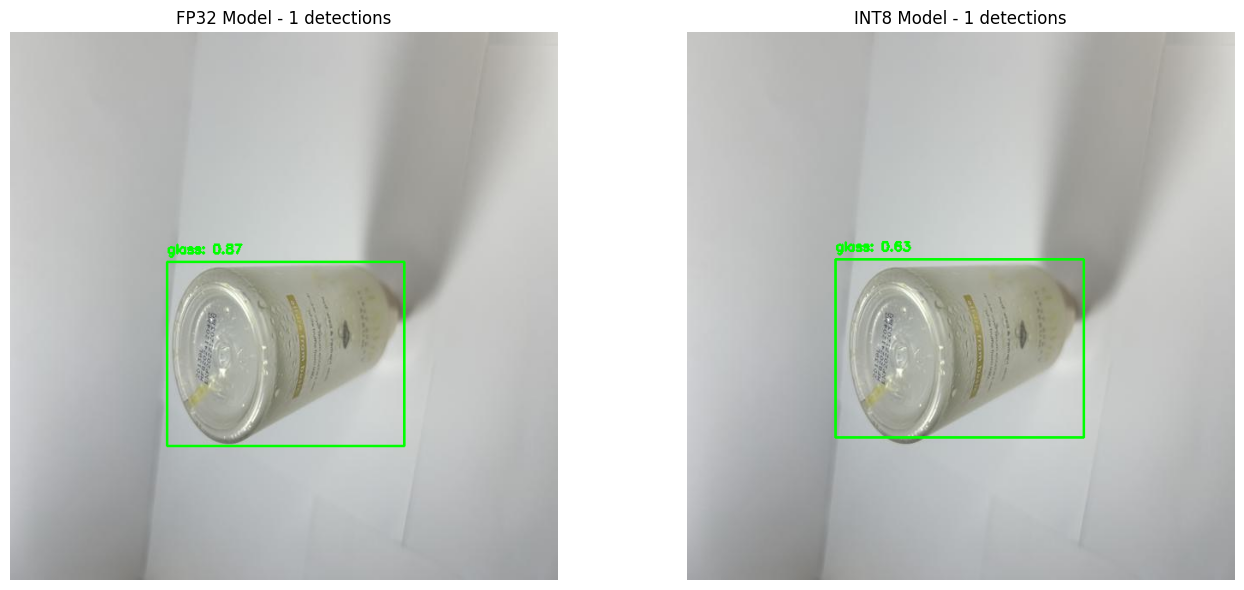


Sample: glass_1001_jpg.rf.0a02e6a8f3cf3804beab975ceb2a6d5b.jpg
  FP32 detections: 1
  INT8 detections: 1


In [19]:
# Compare FP32 vs INT8
print(f"\n{'='*80}")
print(f"FP32 vs INT8 Comparison")
print(f"{'='*80}")

print(f"\nModel Size Comparison:")
print(f"  FP32: {model_size_fp32:.2f} MB")
print(f"  INT8: {model_size_int8:.2f} MB")
print(f"  Reduction: {((model_size_fp32 - model_size_int8) / model_size_fp32 * 100):.1f}%")

print(f"\nLatency Comparison (ms/image):")
print(f"  FP32 Average: {avg_latency_fp32:.2f} ms")
print(f"  INT8 Average: {avg_latency_int8:.2f} ms")
latency_improvement = ((avg_latency_fp32 - avg_latency_int8) / avg_latency_fp32 * 100)
print(f"  Speedup: {latency_improvement:.1f}% {'faster' if latency_improvement > 0 else 'slower'}")

print(f"\nDetection Count Comparison:")
print(f"  FP32: {total_detections_fp32} total detections")
print(f"  INT8: {total_detections_int8} total detections")
print(f"  Difference: {abs(total_detections_fp32 - total_detections_int8)} detections")

# Visualize one sample from each model
print(f"\nVisualizing sample detection results...")
sample_image = val_images[0]
sample_path = os.path.join(val_image_dir, sample_image)

import cv2 as cv
import matplotlib.pyplot as plt

# Get detections from both models
fp32_dets = fp32_inference.predict_image(sample_path, conf=0.35, iou=0.35)
int8_dets = int8_inference.predict_image(sample_path, conf=0.35, iou=0.35)

# Draw boxes
img = cv.imread(sample_path)
img_fp32 = img.copy()
img_int8 = img.copy()

img_fp32 = fp32_inference.draw_boxes(img_fp32, fp32_dets, fp32_inference.classes)
img_int8 = int8_inference.draw_boxes(img_int8, int8_dets, int8_inference.classes)

# Display side-by-side
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].imshow(cv.cvtColor(img_fp32, cv.COLOR_BGR2RGB))
axes[0].set_title(f'FP32 Model - {len(fp32_dets)} detections')
axes[0].axis('off')

axes[1].imshow(cv.cvtColor(img_int8, cv.COLOR_BGR2RGB))
axes[1].set_title(f'INT8 Model - {len(int8_dets)} detections')
axes[1].axis('off')

plt.tight_layout()
plt.show()

print(f"\nSample: {sample_image}")
print(f"  FP32 detections: {len(fp32_dets)}")
print(f"  INT8 detections: {len(int8_dets)}")